## 1. Importer les librairies

In [192]:
import pandas as pd
import numpy as np
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix,ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

## 2. Importer le contenu d'un fichier CSV dans une variable pandas et faire une copie

In [193]:
df=pd.read_csv("simulation_vat_fraud.csv")
df_c=df.copy()

## 3. Séparer les features de la target

In [194]:
# Séparation des variables explicatives de la variable cible.
# Les variables fraud et fraud_type sont supprimées car elles contiennent
# directement l'information recherchée par le modèle.
# vat_number est supprimé car il s'agit uniquement d'un identifiant d'entreprise.
# Les variables vat_due, vat_gap, quarter_turnover_gap et
# quarter_turnover_gap_ratio sont exclues afin d'éviter une potentielle
# fuite d'information. Elles utilisent des montants réels ou des écarts
# entre montants réels et montants déclarés, qui sont considérés comme
# non disponibles au moment où le modèle doit identifier une fraude
# potentielle à partir de la déclaration de l'entreprise.

x = df_c.drop([
    "fraud",
    "fraud_type",
    "vat_number",
    "vat_due",
    "vat_gap",
    "quarter_turnover_gap",
    "quarter_turnover_gap_ratio"
], axis=1
             )

cat_cols = x.select_dtypes(
    include=["object", "category"]
).columns

x = pd.get_dummies(
    x,
    columns=cat_cols
)

In [195]:
print(x)

        year  nacebel_code  employees      turnover  quarter_turnover  \
0       2020         62020          5  2.107519e+05      5.178545e+04   
1       2020         62020          5  2.107519e+05      2.921977e+04   
2       2020         62020          5  2.107519e+05      6.551515e+04   
3       2020         62020          5  2.107519e+05      6.423155e+04   
4       2021         62020          5  2.361568e+05      5.204228e+04   
...      ...           ...        ...           ...               ...   
199995  2023         62010         21  7.940741e+06      2.350679e+06   
199996  2024         62010         21  6.073010e+06      1.650275e+06   
199997  2024         62010         21  6.073010e+06      1.733517e+06   
199998  2024         62010         21  6.073010e+06      5.255328e+05   
199999  2024         62010         21  6.073010e+06      2.163685e+06   

        declared_sales  balance_sheet_total  company_age  \
0         5.178545e+04         70349.826771           35   
1  

In [196]:
y=df_c['fraud']
y

0         0
1         0
2         0
3         0
4         0
         ..
199995    0
199996    0
199997    0
199998    0
199999    0
Name: fraud, Length: 200000, dtype: int64

## 4. Définir les valeurs tests des valeurs d'entraînement

In [197]:
# Séparation des données par entreprise afin d'éviter qu'une même entreprise
# soit présente à la fois dans les données d'entraînement et dans les données de test.
# La fraude étant définie au niveau de l'entreprise, toutes les observations
# d'une même entreprise doivent rester dans le même ensemble.
# Le vat_number est utilisé uniquement pour effectuer ce regroupement
# et n'est pas utilisé comme variable explicative du modèle.

from sklearn.model_selection import train_test_split

# 1. Récupérer les entreprises uniques
company_ids = df_c["vat_number"].unique()

# 2. Séparer les entreprises en train et test
train_companies, test_companies = train_test_split(
    company_ids,
    test_size=0.2,
    random_state=100
)

# 3. Créer les masques
train_mask = df_c["vat_number"].isin(train_companies)
test_mask = df_c["vat_number"].isin(test_companies)

# 4. Créer les données train/test
x_train = x.loc[train_mask]
x_test = x.loc[test_mask]

y_train = y.loc[train_mask]
y_test = y.loc[test_mask]

In [198]:
# Vérification

print("Entreprises train :", df_c.loc[train_mask, "vat_number"].nunique())
print("Entreprises test :", df_c.loc[test_mask, "vat_number"].nunique())

print(
    "Entreprises communes :",
    len(
        set(df_c.loc[train_mask, "vat_number"])
        &
        set(df_c.loc[test_mask, "vat_number"])
    )
)

Entreprises train : 8000
Entreprises test : 2000
Entreprises communes : 0


In [199]:
# Vérification supplémentaire

print("Lignes train :", len(x_train))
print("Lignes test :", len(x_test))

print("Fraudes train :", y_train.sum())
print("Fraudes test :", y_test.sum())

print("Taux fraude train :", y_train.mean())
print("Taux fraude test :", y_test.mean())

Lignes train : 160000
Lignes test : 40000
Fraudes train : 8100
Fraudes test : 2100
Taux fraude train : 0.050625
Taux fraude test : 0.0525


## 5. Entraîner le modèle sans SMOTE

In [200]:
dt = DecisionTreeClassifier(
    criterion="gini",
    max_depth=5,
    random_state=100
)

dt.fit(x_train,y_train)                                                                

,criterion,'gini'
,splitter,'best'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,100
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


## 6. Tester le modèle sans SMOTE

In [201]:
y_pred=dt.predict(x_test)


In [202]:
print("=== SANS SMOTE ===")
print("Accuracy:", accuracy_score(y_test, y_pred)) # pas fiable en cas embalanced classes
print(classification_report(y_test, y_pred)) 

=== SANS SMOTE ===
Accuracy: 0.972625
              precision    recall  f1-score   support

           0       0.97      1.00      0.99     37900
           1       1.00      0.48      0.65      2100

    accuracy                           0.97     40000
   macro avg       0.98      0.74      0.82     40000
weighted avg       0.97      0.97      0.97     40000



Non-fraude :
Le recall de 1,00 indique que le modèle détecte quasiment toutes les observations
réellement non frauduleuses.

Fraude :
La précision de 1,00 indique que lorsque le modèle prédit une fraude, la
prédiction est correcte dans la quasi-totalité des cas.
Cependant, le recall de 0,48 montre que le modèle ne détecte que 48 % des
fraudes réelles. Ainsi, 52 % des fraudes ne sont pas détectées.

Malgré une accuracy élevée de 97,26 %, celle-ci doit être interprétée avec
prudence en raison du déséquilibre entre les classes. Le modèle est très
performant pour identifier les non-fraudes, mais il détecte insuffisamment
les fraudes.

L'utilisation de SMOTE est donc envisagée afin de rééquilibrer les classes
dans les données d'entraînement et d'améliorer la capacité du modèle à
détecter les fraudes.

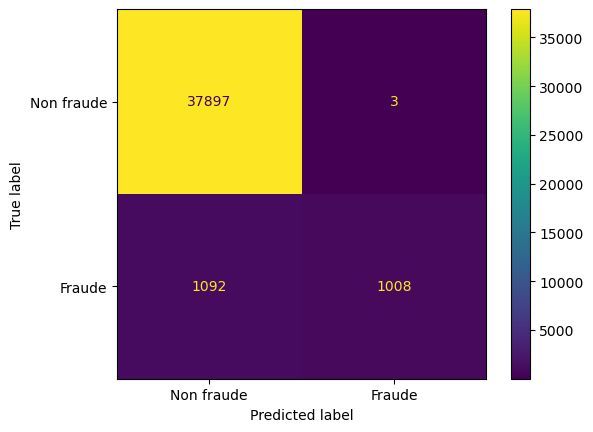

In [203]:
cm=confusion_matrix(y_test,y_pred)
cmd=ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Non fraude","Fraude"]
) 
cmd.plot()
plt.show()

## 7. Equilibrage des classes : utilisation de SMOTE

#### 7.1 Importer librairie

In [204]:
from imblearn.over_sampling import SMOTE

#### 7.2 Créer une instance de la classe SMOTE 

In [205]:
smote=SMOTE(random_state=100)

#### 7.3 rééquilibrer la distribution de classe avec la technique Smote

In [206]:
x_train_smote,y_train_smote=smote.fit_resample(x_train,y_train)

#### 7.4 Création d'un nouveau modèle qui va s'entraîner sur des données dont les classes sont équlibrées

In [207]:
dt_smote=DecisionTreeClassifier(
    criterion="gini",
    max_depth=5,
    random_state=100
)

#### 7.5 Entraînement du modèle avec les données smotées

In [208]:
dt_smote.fit(x_train_smote,y_train_smote)

,criterion,'gini'
,splitter,'best'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,100
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


#### 7.6 Test du modèle avec données smotées

In [209]:
y_pred_smote=dt_smote.predict(x_test)

In [210]:
print("=== AVEC SMOTE ===")
print("Accuracy:", accuracy_score(y_test, y_pred_smote))
print(classification_report(y_test, y_pred_smote))

=== AVEC SMOTE ===
Accuracy: 0.900475
              precision    recall  f1-score   support

           0       0.98      0.91      0.95     37900
           1       0.31      0.73      0.44      2100

    accuracy                           0.90     40000
   macro avg       0.65      0.82      0.69     40000
weighted avg       0.95      0.90      0.92     40000



Non-fraude :
Le recall de 0,91 indique que le modèle détecte 91 % des observations
réellement non frauduleuses.

Fraude :
Le recall passe à 0,73, ce qui signifie que le modèle détecte 73 % des
fraudes réelles. Ainsi, 27 % des fraudes ne sont pas détectées.
La précision de 0,31 indique cependant que parmi les observations
classées comme frauduleuses, seulement 31 % sont réellement des fraudes.
Le modèle produit donc davantage de faux positifs.

Comparaison avec le modèle sans SMOTE :
L'utilisation de SMOTE permet d'améliorer significativement la détection
des fraudes, puisque le recall de la classe fraude passe de 0,48 à 0,73.
En contrepartie, la précision de la classe fraude diminue de 1,00 à 0,31
et l'accuracy globale passe de 97,26 % à 90,05 %.

Ce résultat montre que l'accuracy seule n'est pas suffisante pour évaluer
le modèle dans un contexte de détection de fraude. Le recall de la classe
fraude est particulièrement important, car il permet de mesurer la capacité
du modèle à identifier les fraudes réelles.

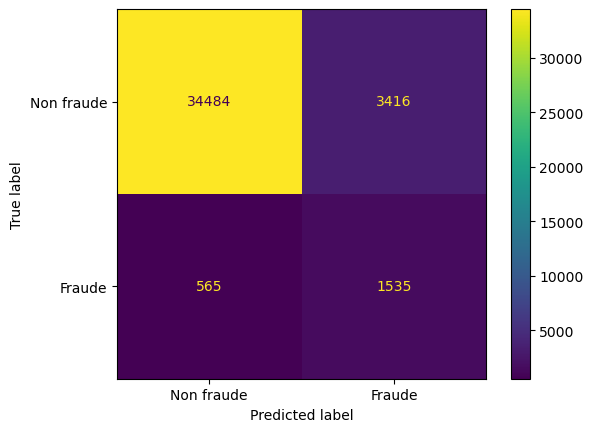

In [211]:
cm_smote = confusion_matrix(y_test, y_pred_smote)
cmd_smote = ConfusionMatrixDisplay(
    cm_smote, 
    display_labels=["Non fraude","Fraude"]
)
cmd_smote.plot()
plt.show()

## 8 Dessin de l'arbre de décision

#### 8.1 Arbre sans SMOTE

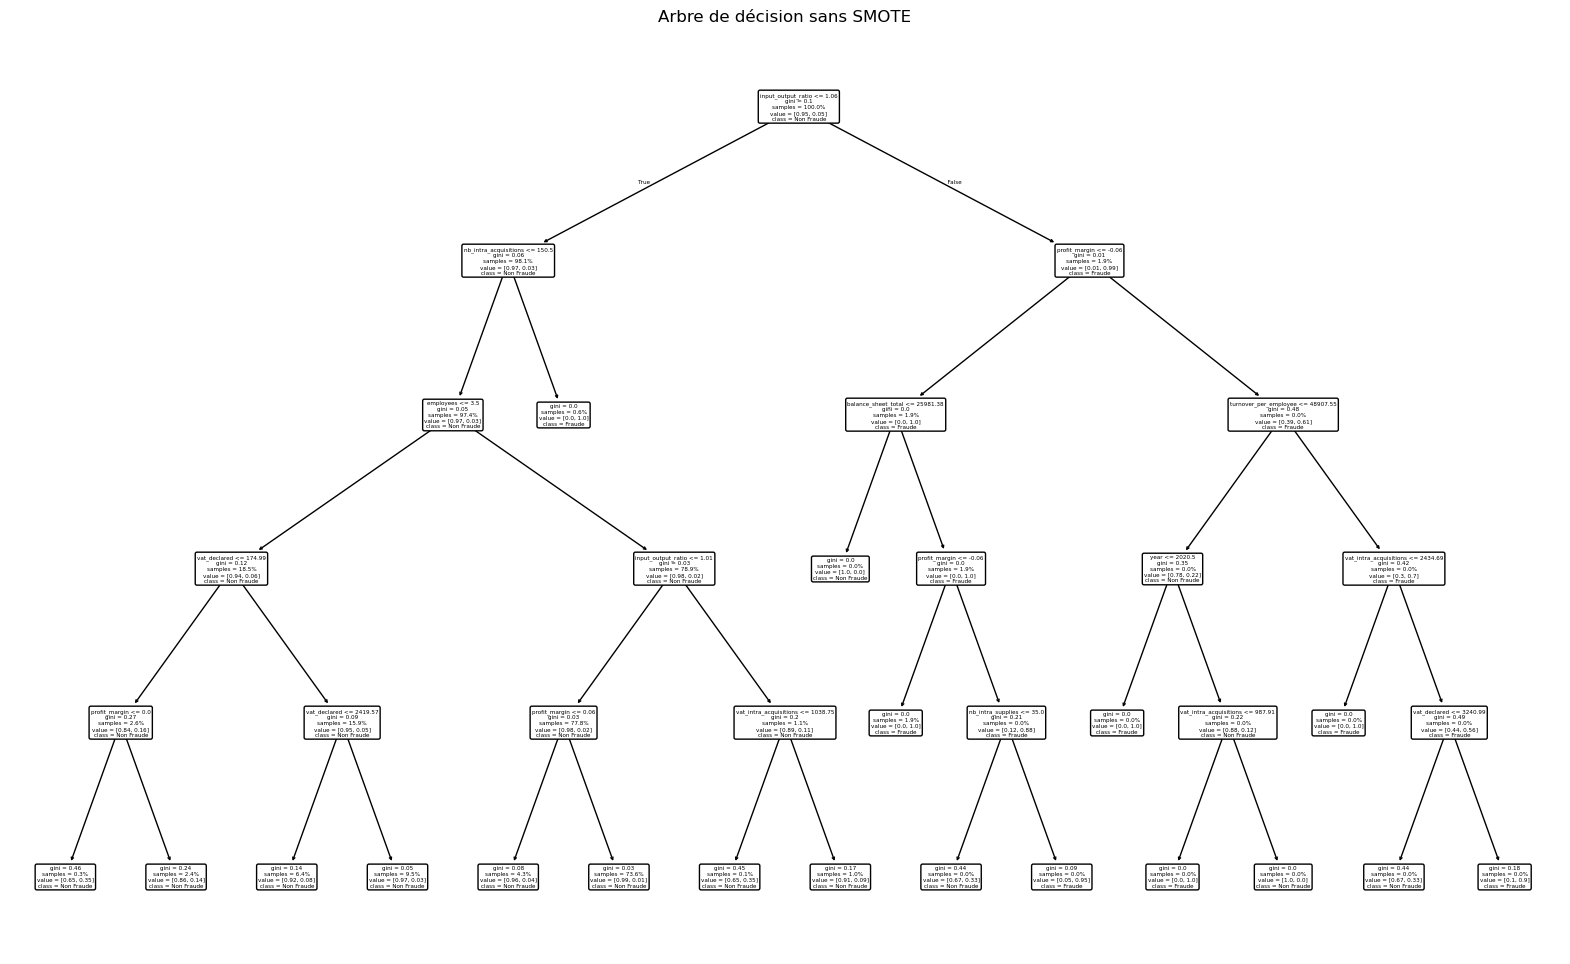

In [212]:
# Créer un espace dessin
plt.figure(figsize=(20,12))

# Dessiner l'arbre
plot_tree(
    dt,
    feature_names=x_train.columns,
    class_names=["Non Fraude", "Fraude"],
    rounded=True,
    proportion=True,
    precision=2
)

plt.title("Arbre de décision sans SMOTE")

# Enregistrer l'arbre sous forme d'image PNG avec une résolution élevée
# (300 dpi) et réduire les marges blanches inutiles autour du graphique.
plt.savefig(
    "arbre_sans_smote.png",# nom du fichier
    dpi=300, # qualité élevée
    bbox_inches="tight" # réduit les marges inutiles
)

# Afficher l'arbre
plt.show()

In [213]:
# Enregistrer l'arbre sans SMOTE au format PDF afin de conserver une bonne qualité
# lors du zoom ou de l'impression, tout en réduisant les marges blanches inutiles.

plt.savefig(
    "arbre_sans_smote.pdf",
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

#### 8.2 Arbre avec SMOTE

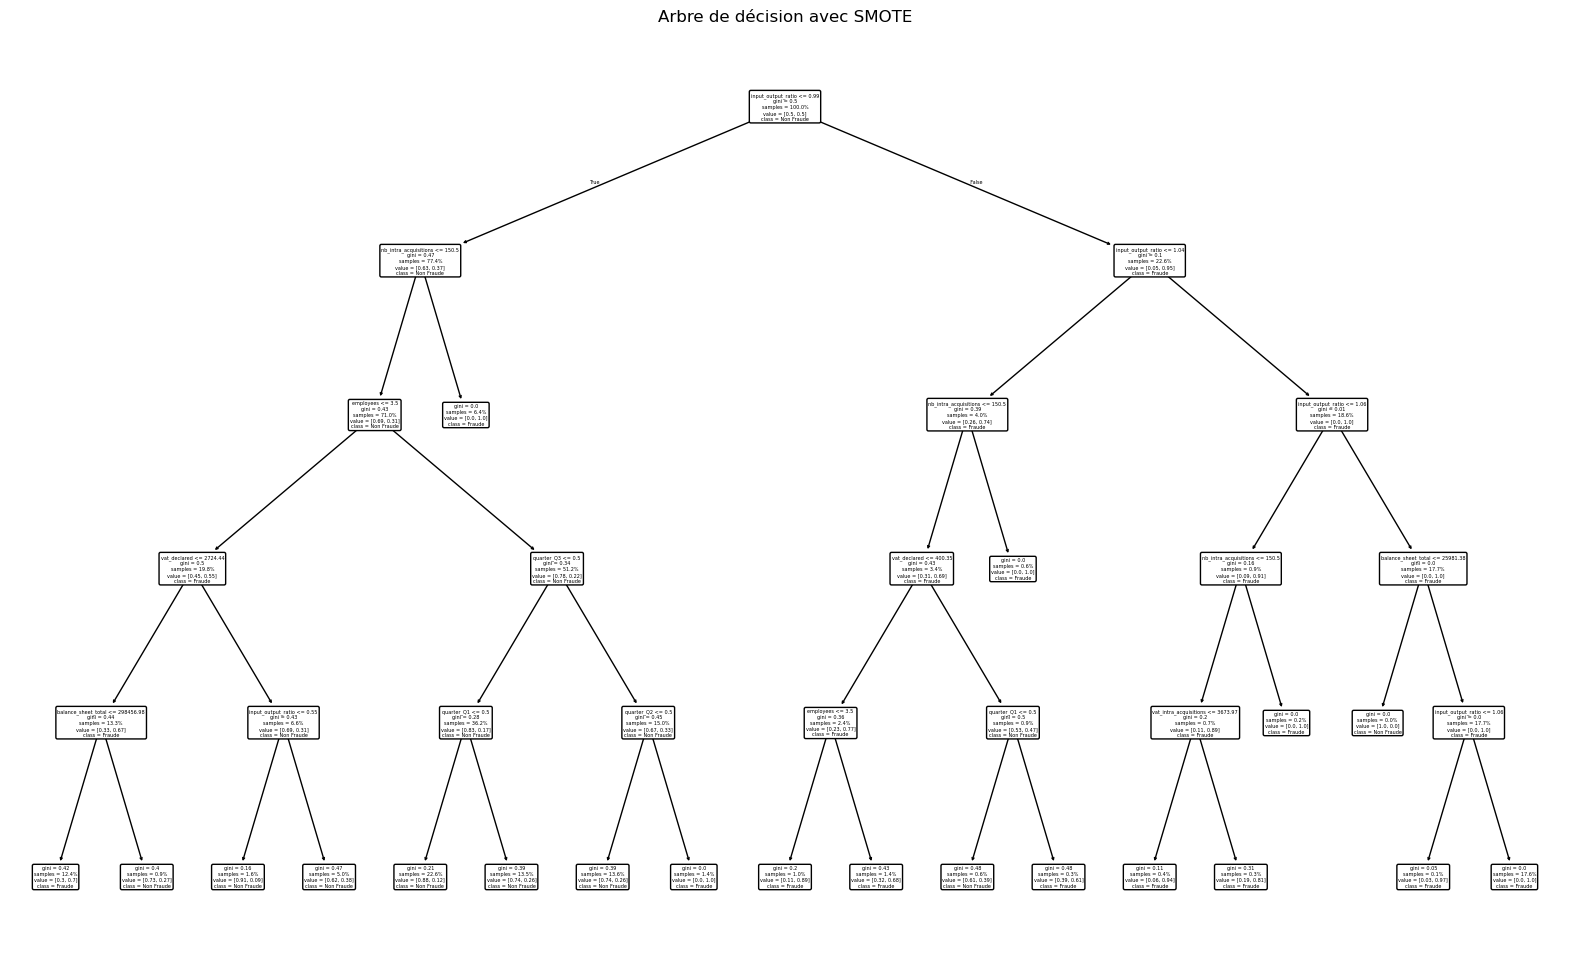

In [250]:
plt.figure(figsize=(20, 12))

plot_tree(
    dt_smote,
    feature_names=x_train_smote.columns,
    class_names=["Non Fraude", "Fraude"],
    rounded=True,
    proportion=True,
    precision=2
)

plt.savefig(
    "arbre_avec_smote.png",
    dpi=300,
    bbox_inches="tight"
)

plt.title("Arbre de décision avec SMOTE")
plt.show()

In [215]:
plt.savefig(
    "arbre_avec_smote.pdf",
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

#### 9. Score de risque

#### 9.1 Calcul du score de risque 

In [216]:
# Le modèle estime pour chaque déclaration la probabilité
# d'appartenir à la classe fraude (classe 1).
proba_risque = dt_smote.predict_proba(x_test)[:, 1]

# Transformation de la probabilité en score compris entre 0 et 100.
score_risque = proba_risque * 100

print(score_risque[:10])

[26.17947471 11.78369888 26.37674825 11.78369888 26.17947471 11.78369888
 26.37674825 11.78369888 26.17947471 11.78369888]


In [217]:
# Création du tableau contenant les résultats du modèle
# pour chaque déclaration du jeu de test.

resultats = df_c.loc[
    test_mask,
    ["vat_number", "year", "quarter", "fraud"]
].copy()

# Ajout du score de risque calculé par le modèle.
resultats["score_risque"] = score_risque

print(resultats.head(20))

      vat_number  year quarter  fraud  score_risque
240  BE129796480  2020      Q1      0     26.179475
241  BE129796480  2020      Q2      0     11.783699
242  BE129796480  2020      Q3      0     26.376748
243  BE129796480  2020      Q4      0     11.783699
244  BE129796480  2021      Q1      0     26.179475
245  BE129796480  2021      Q2      0     11.783699
246  BE129796480  2021      Q3      0     26.376748
247  BE129796480  2021      Q4      0     11.783699
248  BE129796480  2022      Q1      0     26.179475
249  BE129796480  2022      Q2      0     11.783699
250  BE129796480  2022      Q3      0     26.376748
251  BE129796480  2022      Q4      0     11.783699
252  BE129796480  2023      Q1      0     26.179475
253  BE129796480  2023      Q2      0     11.783699
254  BE129796480  2023      Q3      0     26.376748
255  BE129796480  2023      Q4      0     11.783699
256  BE129796480  2024      Q1      0     26.179475
257  BE129796480  2024      Q2      0     11.783699
258  BE12979

In [218]:
# Agrégation du score au niveau de l'entreprise.
# Chaque entreprise possède 20 déclarations dans le jeu de données.
#
# Le 95e percentile est utilisé plutôt que le maximum afin
# de limiter l'influence d'une seule déclaration extrêmement élevée.

score_entreprise = (
    resultats
    .groupby("vat_number")["score_risque"]
    .quantile(0.95)
    .reset_index()
)

score_entreprise.rename(
    columns={"score_risque": "score_risque_entreprise"},
    inplace=True
)

print(score_entreprise.head(20))

     vat_number  score_risque_entreprise
0   BE100044950                26.376748
1   BE100048840                69.823683
2   BE100125053                27.027446
3   BE100142953                26.376748
4   BE100148412                69.823683
5   BE100204571                69.823683
6   BE100248033                26.376748
7   BE100252993                26.376748
8   BE100265032                26.376748
9   BE100292915                26.376748
10  BE100358601                27.027446
11  BE100442156                26.376748
12  BE100447007                26.376748
13  BE100510320                69.823683
14  BE100529938                26.376748
15  BE100711428                70.377953
16  BE100745031                69.823683
17  BE100819608                26.376748
18  BE100876517                26.376748
19  BE100921563                26.376748


In [219]:
# ============================================================
# 1. CALCUL DES SEUILS
# ============================================================

# Détermination des seuils à partir de la distribution
# des scores de risque des entreprises.

seuil_moyen = score_entreprise[
    "score_risque_entreprise"
].quantile(0.70)

seuil_eleve = score_entreprise[
    "score_risque_entreprise"
].quantile(0.95)

print("Seuil risque moyen :", seuil_moyen)
print("Seuil risque élevé :", seuil_eleve)

Seuil risque moyen : 29.103365384615422
Seuil risque élevé : 88.93141945773525


In [220]:
# ============================================================
# 2. ATTRIBUTION DU NIVEAU DE RISQUE
# ============================================================

# Attribution du niveau de risque à chaque entreprise.
# Les entreprises situées dans les 5 % de scores les plus élevés
# sont classées comme présentant un risque élevé.
# Les entreprises situées entre les 70e et 95e percentiles
# sont classées comme présentant un risque moyen.
# Les autres sont classées comme présentant un risque faible.

def niveau_risque_entreprise(score):
    if score >= seuil_eleve:
        return "Élevé"
    elif score >= seuil_moyen:
        return "Moyen"
    else:
        return "Faible"

# Application du niveau de risque à chaque entreprise.
score_entreprise["niveau_risque"] = (
    score_entreprise["score_risque_entreprise"]
    .apply(niveau_risque_entreprise)
)

In [234]:
# Vérification de la fraude réelle selon le niveau de risque

fraude_par_niveau = (
    evaluation_risque
    .groupby("niveau_risque")["fraud_entreprise"]
    .mean()
    .mul(100)
    .round(2)
)

print("Taux de fraude réelle par niveau de risque :")
print(fraude_par_niveau)

Taux de fraude réelle par niveau de risque :
niveau_risque
Faible     0.00
Moyen      1.61
Élevé     91.51
Name: fraud_entreprise, dtype: float64


In [221]:
# ============================================================
# 3. FRAUDE RÉELLE AU NIVEAU DE L'ENTREPRISE
# ============================================================

# Création de l'information réelle de fraude au niveau de l'entreprise.
# Une entreprise est considérée comme frauduleuse si au moins une
# de ses déclarations est frauduleuse.

fraude_entreprise = (
    df_c.groupby("vat_number")["fraud"]
    .max()
    .reset_index()
)

fraude_entreprise.rename(
    columns={"fraud": "fraud_entreprise"},
    inplace=True
)


    vat_number  score_risque_entreprise niveau_risque  fraud_entreprise
0  BE100044950                26.376748        Faible                 0
1  BE100048840                69.823683         Moyen                 0
2  BE100125053                27.027446        Faible                 0
3  BE100142953                26.376748        Faible                 0
4  BE100148412                69.823683         Moyen                 0
Index(['vat_number', 'score_risque_entreprise', 'niveau_risque',
       'fraud_entreprise'],
      dtype='object')


In [237]:
# ============================================================
# 4. TABLE D'ÉVALUATION
# ============================================================

# Création du tableau permettant d'évaluer la pertinence
# du classement des entreprises selon leur niveau de risque.

evaluation_risque = score_entreprise[
    ["vat_number", "score_risque_entreprise", "niveau_risque"]
].merge(
    fraude_entreprise,
    on="vat_number",
    how="left"
)

print(evaluation_risque.head())
print(evaluation_risque.columns)

    vat_number  score_risque_entreprise niveau_risque  fraud_entreprise
0  BE100044950                26.376748        Faible                 0
1  BE100048840                69.823683         Moyen                 0
2  BE100125053                27.027446        Faible                 0
3  BE100142953                26.376748        Faible                 0
4  BE100148412                69.823683         Moyen                 0
Index(['vat_number', 'score_risque_entreprise', 'niveau_risque',
       'fraud_entreprise'],
      dtype='object')


In [238]:
# Pourcentage d'entreprises réellement frauduleuses
# dans chaque niveau de risque.

fraude_par_niveau = (
    evaluation_risque
    .groupby("niveau_risque")["fraud_entreprise"]
    .mean()
    .mul(100)
    .round(2)
)

print(fraude_par_niveau)


niveau_risque
Faible     0.00
Moyen      1.61
Élevé     91.51
Name: fraud_entreprise, dtype: float64


In [223]:
# Vérification de la variable fraud dans le DataFrame actuel.

print("Nombre total de lignes :", len(df_c))

print("\nRépartition de fraud :")
print(df_c["fraud"].value_counts())

print("\nTaux de fraude par ligne :")
print(df_c["fraud"].mean())

print("\nNombre d'entreprises uniques :")
print(df_c["vat_number"].nunique())

print("\nFraude au niveau entreprise :")
fraude_par_entreprise = (
    df_c.groupby("vat_number")["fraud"]
    .max()
)

print(fraude_par_entreprise.value_counts())

print("\nTaux de fraude au niveau entreprise :")
print(fraude_par_entreprise.mean() * 100)

Nombre total de lignes : 200000

Répartition de fraud :
fraud
0    189800
1     10200
Name: count, dtype: int64

Taux de fraude par ligne :
0.051

Nombre d'entreprises uniques :
10000

Fraude au niveau entreprise :
fraud
0    9490
1     510
Name: count, dtype: int64

Taux de fraude au niveau entreprise :
5.1


In [224]:
print("=== TRAIN ===")

fraude_train = (
    df_c.loc[train_mask]
    .groupby("vat_number")["fraud"]
    .max()
)

print("Entreprises :", len(fraude_train))
print("Fraudes :", fraude_train.sum())
print("Taux :", fraude_train.mean() * 100)


print("\n=== TEST ===")

fraude_test = (
    df_c.loc[test_mask]
    .groupby("vat_number")["fraud"]
    .max()
)

print("Entreprises :", len(fraude_test))
print("Fraudes :", fraude_test.sum())
print("Taux :", fraude_test.mean() * 100)

=== TRAIN ===
Entreprises : 8000
Fraudes : 405
Taux : 5.0625

=== TEST ===
Entreprises : 2000
Fraudes : 105
Taux : 5.25


In [225]:
# Vérification : la variable fraud doit être constante
# pour les 20 déclarations de chaque entreprise.

fraud_par_entreprise = (
    df_c.groupby("vat_number")["fraud"]
    .nunique()
)

print(fraud_par_entreprise.value_counts())

fraud
1    10000
Name: count, dtype: int64


#### 9.5 Vérifications de la répartition des entreprises

In [226]:
# Vérification de la répartition des entreprises
# selon leur niveau de risque.

print(
    score_entreprise["niveau_risque"].value_counts()
)

print("\nPourcentages :")

print(
    score_entreprise["niveau_risque"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

niveau_risque
Faible    1396
Moyen      498
Élevé      106
Name: count, dtype: int64

Pourcentages :
niveau_risque
Faible    69.8
Moyen     24.9
Élevé      5.3
Name: proportion, dtype: float64


In [227]:
print(evaluation_risque.columns)

Index(['vat_number', 'score_risque_entreprise', 'niveau_risque',
       'fraud_entreprise'],
      dtype='object')


In [228]:
# Pourcentage d'entreprises réellement frauduleuses
# dans chaque niveau de risque.

fraude_par_niveau = (
    evaluation_risque
    .groupby("niveau_risque")["fraud_entreprise"]
    .mean()
    .mul(100)
    .round(2)
)

print(fraude_par_niveau)

niveau_risque
Faible     0.00
Moyen      1.61
Élevé     91.51
Name: fraud_entreprise, dtype: float64


#### 9.6 Visualiser les niveaux de risque

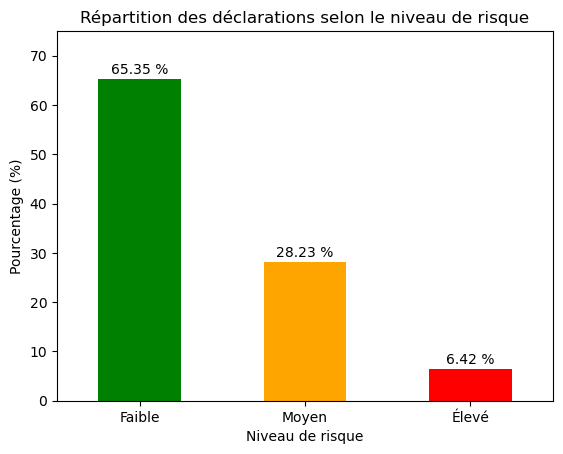

In [229]:
# Visualisation de la répartition des déclarations
# selon leur niveau de risque.

repartition = (
    pd.Series(niveaux_risque)
    .value_counts()
    .reindex(["Faible", "Moyen", "Élevé"])
)

repartition_pct = repartition / repartition.sum() * 100

repartition_pct.plot(
    kind="bar",
    color=["green", "orange", "red"]
)

plt.title("Répartition des déclarations selon le niveau de risque")
plt.xlabel("Niveau de risque")
plt.ylabel("Pourcentage (%)")
plt.xticks(rotation=0)

# Affichage du pourcentage au-dessus de chaque barre
for i, valeur in enumerate(repartition_pct):
    plt.text(
        i,
        valeur + 1,
        f"{valeur:.2f} %",
        ha="center"
    )

plt.ylim(0, 75)
plt.show()

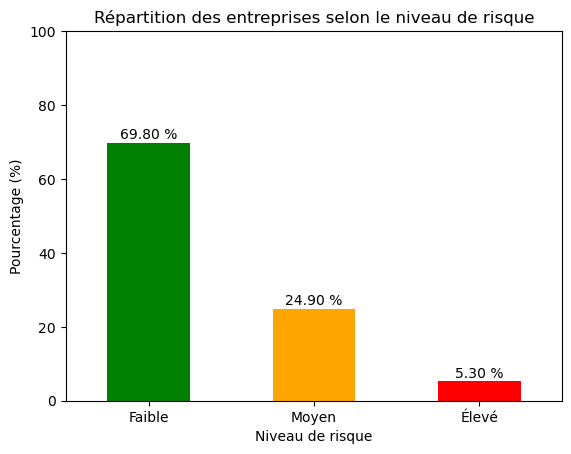

In [230]:
# Répartition des entreprises selon leur niveau de risque

repartition_entreprises = (
    score_entreprise["niveau_risque"]
    .value_counts()
    .reindex(["Faible", "Moyen", "Élevé"])
    .fillna(0)
)

repartition_entreprises_pct = (
    repartition_entreprises
    / repartition_entreprises.sum()
    * 100
)

repartition_entreprises_pct.plot(
    kind="bar",
    color=["green", "orange", "red"]
)

plt.title("Répartition des entreprises selon le niveau de risque")
plt.xlabel("Niveau de risque")
plt.ylabel("Pourcentage (%)")
plt.xticks(rotation=0)

for i, valeur in enumerate(repartition_entreprises_pct):
    plt.text(
        i,
        valeur + 1,
        f"{valeur:.2f} %",
        ha="center"
    )

plt.ylim(0, 100)
plt.show()

In [231]:
print(
    pd.Series(score_risque).describe()
)

count    40000.000000
mean        27.272342
std         20.757030
min          8.973018
25%         11.783699
50%         26.179475
75%         26.376748
max        100.000000
dtype: float64


In [232]:
# Vérification de la répartition des niveaux de risque

print(
    pd.Series(niveaux_risque).value_counts()
)

print(
    pd.Series(niveaux_risque)
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

Faible    26139
Moyen     11293
Élevé      2568
Name: count, dtype: int64
Faible    65.35
Moyen     28.23
Élevé      6.42
Name: proportion, dtype: float64


## 10. Vérification finale du modèle

In [235]:
# Nombre d'entreprises frauduleuses par niveau de risque

fraudes_par_niveau = (
    evaluation_risque[
        evaluation_risque["fraud_entreprise"] == 1
    ]
    ["niveau_risque"]
    .value_counts()
)

print("Entreprises réellement frauduleuses par niveau :")
print(fraudes_par_niveau)

Entreprises réellement frauduleuses par niveau :
niveau_risque
Élevé    97
Moyen     8
Name: count, dtype: int64


In [236]:
# Part des fraudes réellement détectées dans chaque niveau

total_fraudes = evaluation_risque["fraud_entreprise"].sum()

fraudes_detectees = (
    evaluation_risque[
        evaluation_risque["fraud_entreprise"] == 1
    ]
    ["niveau_risque"]
    .value_counts()
    .sort_index()
)

print("Total entreprises frauduleuses :", total_fraudes)
print("\nRépartition des fraudes par niveau :")
print(
    (fraudes_detectees / total_fraudes * 100)
    .round(2)
)

Total entreprises frauduleuses : 105

Répartition des fraudes par niveau :
niveau_risque
Moyen     7.62
Élevé    92.38
Name: count, dtype: float64


#### 11. Fiche explicative du risque

#### 11.1 Choix de l'entreprise à expliquer

In [242]:
index_entreprise = 0

observation = x_test.iloc[[index_entreprise]].values

print("Entreprise sélectionnée :", index_entreprise)

Entreprise sélectionnée : 0


#### 11.2 Calcul du score

In [243]:
proba = dt_smote.predict_proba(observation)[0, 1]
score = proba * 100

print("Score de risque :", round(score, 2), "/ 100")

Score de risque : 26.18 / 100


/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


#### 11.3 Niveau de risque

In [244]:
niveau = niveau_risque_entreprise(score)

print("Niveau de risque :", niveau)

Niveau de risque : Faible


#### 11.4 Contributions

In [247]:
feature_names = x_train.columns.tolist()

print("Nombre de variables :", len(feature_names))
print(feature_names)

Nombre de variables : 43
['year', 'nacebel_code', 'employees', 'turnover', 'quarter_turnover', 'declared_sales', 'balance_sheet_total', 'company_age', 'public_interest_entity', 'sales', 'purchases', 'sales_6', 'sales_12', 'sales_21', 'intra_community_supplies', 'purchases_6', 'purchases_12', 'purchases_21', 'intra_community_acquisitions', 'nb_intra_supplies', 'nb_intra_acquisitions', 'vat_sales_6', 'vat_sales_12', 'vat_sales_21', 'vat_purchases_6', 'vat_purchases_12', 'vat_purchases_21', 'total_vat_sales', 'total_vat_purchases', 'vat_intra_acquisitions', 'vat_deductible_intra', 'vat_declared', 'profit_margin', 'input_output_ratio', 'turnover_per_employee', 'quarter_Q1', 'quarter_Q2', 'quarter_Q3', 'quarter_Q4', 'company_size_Grande', 'company_size_Micro', 'company_size_Petite', 'company_size_Très Grande']


In [248]:
# Calcul des contributions
contributions = calculer_contributions_arbre(
    dt_smote,
    observation,
    feature_names
)

print(contributions)

                variable  contribution                sens
0     input_output_ratio    -13.112510   Diminue le risque
1  nb_intra_acquisitions     -5.712493   Diminue le risque
2              employees     -9.223307   Diminue le risque
3             quarter_Q3     -4.780515   Diminue le risque
4             quarter_Q1      9.008300  Augmente le risque


/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


#### 11.5 Fiche finale

In [249]:
print("=" * 60)
print("FICHE EXPLICATIVE DU RISQUE")
print("=" * 60)

print(f"Score de risque : {score:.2f} / 100")
print(f"Niveau de risque : {niveau}")

print("\nFACTEURS AUGMENTANT LE RISQUE")
print("-" * 60)

facteurs_positifs = contributions[
    contributions["contribution"] > 0
].sort_values(
    "contribution",
    ascending=False
)

print(
    facteurs_positifs[
        ["variable", "contribution"]
    ].to_string(index=False)
)

print("\nFACTEURS DIMINUANT LE RISQUE")
print("-" * 60)

facteurs_negatifs = contributions[
    contributions["contribution"] < 0
].sort_values(
    "contribution"
)

print(
    facteurs_negatifs[
        ["variable", "contribution"]
    ].to_string(index=False)
)

FICHE EXPLICATIVE DU RISQUE
Score de risque : 26.18 / 100
Niveau de risque : Faible

FACTEURS AUGMENTANT LE RISQUE
------------------------------------------------------------
  variable  contribution
quarter_Q1        9.0083

FACTEURS DIMINUANT LE RISQUE
------------------------------------------------------------
             variable  contribution
   input_output_ratio    -13.112510
            employees     -9.223307
nb_intra_acquisitions     -5.712493
           quarter_Q3     -4.780515
